In [14]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [15]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [16]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [17]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [18]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [19]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

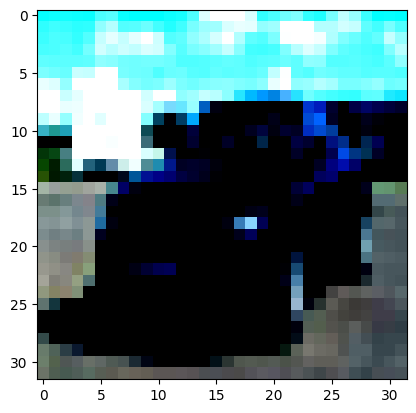

In [20]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [21]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [22]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [23]:
config = {
    'num_epochs': 10,
    'lr': 0.001,
    'batch_size': 128,
    'test_size': 0.2
}

In [24]:
class Trainer:

    def __init__(self, config, model, transform):

        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)

        self.loss_function = nn.CrossEntropyLoss()

        self.train_losses = []
        self.val_losses = []
        self.val_accs = []

        self.setup_dataloaders()

    def setup_dataloaders(self):

        train_dataset_full = CIFAR10(root='cifar10', train=True,
                                     download=True, transform=self.transform)

        test_dataset = CIFAR10(root='cifar10', train=False,
                               download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )

        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(
            train_dataset,
            batch_size=self.config['batch_size'],
            shuffle=True
        )

        self.val_loader = DataLoader(
            val_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False
        )

        self.test_loader = DataLoader(
            test_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False
        )

    def run(self):

        for epoch in range(self.config['num_epochs']):

            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)

            print(f"Epoch {epoch+1}/{self.config['num_epochs']}",
                  f"Train loss {train_loss:.4f}",
                  f"Val loss {val_loss:.4f}",
                  f"Val acc {val_acc:.2f}")

        test_loss, test_acc = self.test_step()

        print(f"Test loss {test_loss:.4f}, Test acc {test_acc:.2f}")

    def train_step(self):

        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(self.train_loader):

            images = images.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)

            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        self.scheduler.step()

        return total_loss / len(self.train_loader), correct / total * 100

    def val_step(self):

        self.model.eval()

        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in tqdm(self.val_loader):

                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)

                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        return total_loss / len(self.val_loader), correct / total * 100

    def test_step(self):

        self.model.eval()

        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in tqdm(self.test_loader):

                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)

                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        return total_loss / len(self.test_loader), correct / total * 100

In [25]:
trainer_cnn = Trainer(config, BasicCNN(), transform)
trainer_cnn.run()

100%|██████████| 79/79 [00:02<00:00, 27.99it/s]


Epoch 1/10 Train loss 1.5767 Val loss 1.3357 Val acc 51.66


100%|██████████| 79/79 [00:03<00:00, 25.73it/s]


Epoch 2/10 Train loss 1.2381 Val loss 1.1663 Val acc 59.31


100%|██████████| 79/79 [00:02<00:00, 32.14it/s]


...

Epoch 9/10 Train loss 0.7047 Val loss 0.8343 Val acc 71.26


100%|██████████| 79/79 [00:02<00:00, 32.74it/s]


Epoch 10/10 Train loss 0.6922 Val loss 0.8304 Val acc 70.97


100%|██████████| 79/79 [00:02<00:00, 32.99it/s]

Test loss 0.8500, Test acc 70.89


# ResNet-18

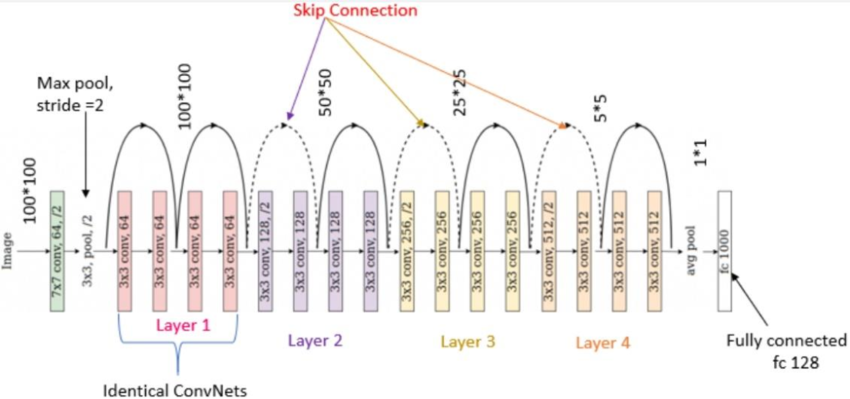

In [26]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity
        out = F.relu(out)

        return out

class ResNet18(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):

        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            ResNetBlock(self.in_channels, out_channels, stride, downsample)
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                ResNetBlock(self.in_channels, out_channels)
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [28]:
trainer_resnet = Trainer(config, ResNet18(), transform)
trainer_resnet.run()

100%|██████████| 79/79 [00:03<00:00, 25.23it/s]


Epoch 1/10 Train loss 1.4266 Val loss 1.1261 Val acc 59.65


100%|██████████| 79/79 [00:03<00:00, 21.44it/s]


Epoch 2/10 Train loss 1.0245 Val loss 0.9532 Val acc 65.99


100%|██████████| 79/79 [00:03<00:00, 23.51it/s]


...

Epoch 9/10 Train loss 0.1450 Val loss 0.8087 Val acc 78.03


100%|██████████| 79/79 [00:02<00:00, 26.91it/s]


Epoch 10/10 Train loss 0.0996 Val loss 0.9133 Val acc 77.48


100%|██████████| 79/79 [00:03<00:00, 23.67it/s]

Test loss 0.9499, Test acc 77.12


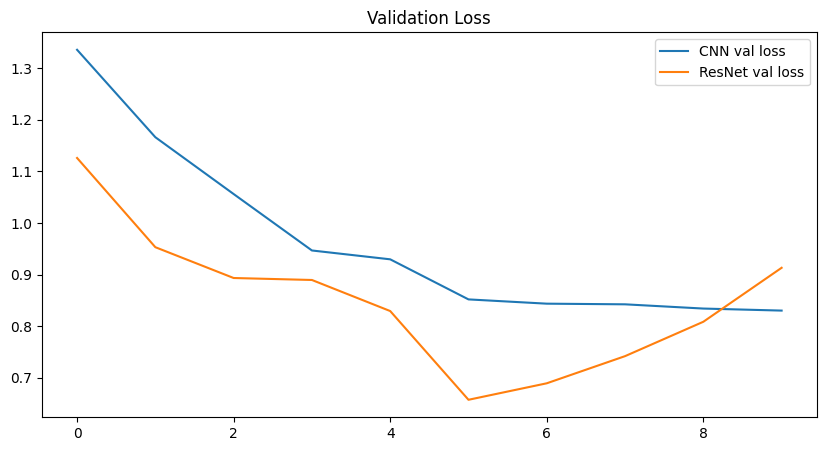

In [29]:
plt.figure(figsize=(10,5))

plt.plot(trainer_cnn.val_losses, label='CNN val loss')
plt.plot(trainer_resnet.val_losses, label='ResNet val loss')

plt.legend()
plt.title("Validation Loss")
plt.show()

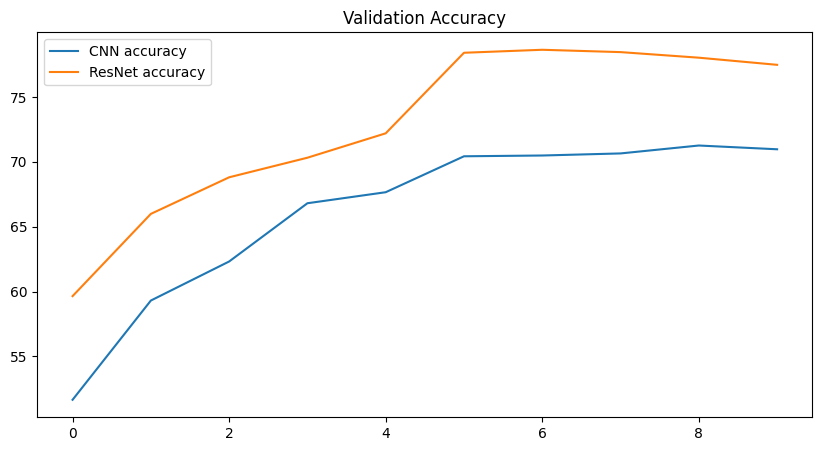

In [30]:
plt.figure(figsize=(10,5))

plt.plot(trainer_cnn.val_accs, label='CNN accuracy')
plt.plot(trainer_resnet.val_accs, label='ResNet accuracy')

plt.legend()
plt.title("Validation Accuracy")
plt.show()

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def compute_metrics(model, loader, device):

    model.eval()

    preds_all = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1).cpu()

            preds_all.extend(preds.numpy())
            labels_all.extend(labels.numpy())

    acc = accuracy_score(labels_all, preds_all)
    precision = precision_score(labels_all, preds_all, average='macro')
    recall = recall_score(labels_all, preds_all, average='macro')
    f1 = f1_score(labels_all, preds_all, average='macro')

    return acc, precision, recall, f1

In [33]:
cnn_metrics = compute_metrics(
    trainer_cnn.model,
    trainer_cnn.test_loader,
    trainer_cnn.device
)

print("CNN metrics")
print("Accuracy:", cnn_metrics[0])
print("Precision:", cnn_metrics[1])
print("Recall:", cnn_metrics[2])
print("F1:", cnn_metrics[3])

CNN metrics
Accuracy: 0.7089
Precision: 0.7103970399097794
Recall: 0.7089
F1: 0.708891264665068


In [34]:
resnet_metrics = compute_metrics(
    trainer_resnet.model,
    trainer_resnet.test_loader,
    trainer_resnet.device
)

print("\nResNet metrics")
print("Accuracy:", resnet_metrics[0])
print("Precision:", resnet_metrics[1])
print("Recall:", resnet_metrics[2])
print("F1:", resnet_metrics[3])


ResNet metrics
Accuracy: 0.7712
Precision: 0.7725599420981841
Recall: 0.7712000000000001
F1: 0.7713518631715964


**ВЫВОД**

ResNet18 показала более высокую точность и лучшее качество классификации. Простая CNN обучается быстрее, но уступает по метрикам.

Основная причина лучшего качества ResNet — использование residual connections, которые позволяют обучать более глубокие сети и уменьшают проблему затухающего градиента.